<div style="text-align: center;">

<h2 style="font-weight: normal;">
CIVE 202 – Project #5: Analysis of Total Coliform Rule (TCR) Violations (2021–2025)
</h2>

<p><strong>Client:</strong> UMass Amherst Water Research Team</p>

<p><strong>Group:</strong> ENVRN-02-06</p>

<p>
CIVE 202 – Civil Engineering Analysis II<br>
University of Nebraska–Lincoln<br>
Spring 2026
</p>

</div>

**Step One: Load and Clean Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
!{sys.executable} -m pip install statsmodels
import plotly.express as px


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df_2021_Q1 = pd.read_csv("2021_Q1.csv", skiprows=4, dtype=str, encoding="latin1")
df_2021_Q2 = pd.read_csv("2021_Q2.csv", skiprows=4, dtype=str, encoding="latin1")
df_2021_Q3 = pd.read_csv("2021_Q3.csv", skiprows=4, dtype=str, encoding="latin1")
df_2021_Q4 = pd.read_csv("2021_Q4.csv", skiprows=4, dtype=str, encoding="latin1")

df_2022_Q1 = pd.read_csv("2022_Q1.csv", skiprows=4, dtype=str, encoding="latin1")
df_2022_Q2 = pd.read_csv("2022_Q2.csv", skiprows=4, dtype=str, encoding="latin1")
df_2022_Q3 = pd.read_csv("2022_Q3.csv", skiprows=4, dtype=str, encoding="latin1")
df_2022_Q4 = pd.read_csv("2022_Q4.csv", skiprows=4, dtype=str, encoding="latin1")

df_2023_Q1 = pd.read_csv("2023_Q1.csv", skiprows=4, dtype=str, encoding="latin1")
df_2023_Q2 = pd.read_csv("2023_Q2.csv", skiprows=4, dtype=str, encoding="latin1")
df_2023_Q3 = pd.read_csv("2023_Q3.csv", skiprows=4, dtype=str, encoding="latin1")
df_2023_Q4 = pd.read_csv("2023_Q4.csv", skiprows=4, dtype=str, encoding="latin1")

df_2024_Q1 = pd.read_csv("2024_Q1.csv", skiprows=4, dtype=str, encoding="latin1")
df_2024_Q2 = pd.read_csv("2024_Q2.csv", skiprows=4, dtype=str, encoding="latin1")
df_2024_Q3 = pd.read_csv("2024_Q3.csv", skiprows=4, dtype=str, encoding="latin1")
df_2024_Q4 = pd.read_csv("2024_Q4.csv", skiprows=4, dtype=str, encoding="latin1")

df_2025_Q1 = pd.read_csv("2025_Q1.csv", skiprows=4, dtype=str, encoding="latin1")
df_2025_Q2 = pd.read_csv("2025_Q2.csv", skiprows=4, dtype=str, encoding="latin1")
df_2025_Q3 = pd.read_csv("2025_Q3.csv", skiprows=4, dtype=str, encoding="latin1")
df_2025_Q4 = pd.read_csv("2025_Q4.csv", skiprows=4, dtype=str, encoding="latin1")

In [4]:
vio_data = pd.concat([
    df_2021_Q1, df_2021_Q2, df_2021_Q3, df_2021_Q4,
    df_2022_Q1, df_2022_Q2, df_2022_Q3, df_2022_Q4,
    df_2023_Q1, df_2023_Q2, df_2023_Q3, df_2023_Q4,
    df_2024_Q1, df_2024_Q2, df_2024_Q3, df_2024_Q4,
    df_2025_Q1, df_2025_Q2, df_2025_Q3, df_2025_Q4
], ignore_index=True)

print(vio_data.head())
print(vio_data.columns)

  Submission Year Quarter EPA Region Primacy Agency Code Primacy Type  \
0                  2021Q1          1                  MA        State   
1                  2021Q1          1                  MA        State   
2                  2021Q1          1                  MA        State   
3                  2021Q1          1                  MA        State   
4                  2021Q1          1                  MA        State   

      PWS ID                               PWS Name  \
0  MA4334001  WESTPORT HARBOR WATER ASSOCIATION INC   
1  MA1341024                  1896 HOUSE RESTAURANT   
2  MA4239010                           MCI PLYMOUTH   
3  MA4239049        HERRING COVE CONDOMINIUMS TRUST   
4  MA4285003             COPPERWOOD II CONDOMINIUMS   

                             PWS Type          GW SW  \
0  Non-Transient non-community system  Surface water   
1      Transient non-community system  Surface water   
2              Community water system    Groundwater   
3     

In [5]:
vio_data.columns = (
    vio_data.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

vio_data.columns

Index(['submission_year_quarter', 'epa_region', 'primacy_agency_code',
       'primacy_type', 'pws_id', 'pws_name', 'pws_type', 'gw_sw',
       'primary_source', 'pws_activity_type', 'pws_deactivation_date',
       'population_served_count', 'pop_cat_5', 'violation_id',
       'is_health_based', 'rule_name', 'violation_type',
       'compliance_period_begin_date', 'compliance_period_end_date',
       'compliance_status', 'rtc_date'],
      dtype='object')

In [6]:
vio_data['population_served_count_clean'] = (
    vio_data['population_served_count']
    .str.replace(",", "", regex=False)
    .str.strip()
)

vio_data['population_served_count_clean'] = pd.to_numeric(
    vio_data['population_served_count_clean'],
    errors='coerce'
)

vio_data[['population_served_count', 'population_served_count_clean']].head()

,population_served_count,population_served_count_clean
0,200,200
1,34,34
2,210,210
3,25,25
4,75,75


In [7]:
vio_data['year'] = vio_data['submission_year_quarter'].str[:4]

vio_data[['submission_year_quarter', 'year']].head()

,submission_year_quarter,year
0,2021Q1,2021
1,2021Q1,2021
2,2021Q1,2021
3,2021Q1,2021
4,2021Q1,2021


In [8]:
violations_by_state = vio_data.groupby('primacy_agency_code').size().reset_index(name='total_violations')
print(violations_by_state)

  primacy_agency_code  total_violations
0                  GA            242850
1                  MA            145154
2                  OH            508295
3                  TX            393033
4                  WA            524368


In [9]:
violations_by_popcat = vio_data.groupby('pop_cat_5').size().reset_index(name='total_violations')
print(violations_by_popcat)

        pop_cat_5  total_violations
0  10,001-100,000             55147
1    3,301-10,000             67614
2       501-3,300            219381
3           <=500           1468748
4        >100,000              2810


In [10]:
violations_by_year = vio_data.groupby('year').size().reset_index(name='total_violations')
print(violations_by_year)

   year  total_violations
0  2021            373529
1  2022            368536
2  2023            363343
3  2024            356511
4  2025            351781


In [11]:
violations_by_state.columns = ['State', 'Total Violations']
violations_by_popcat.columns = ['System Size', 'Total Violations']
violations_by_year.columns = ['Year', 'Total Violations']

**Step Two: Graph Cleaned Data**

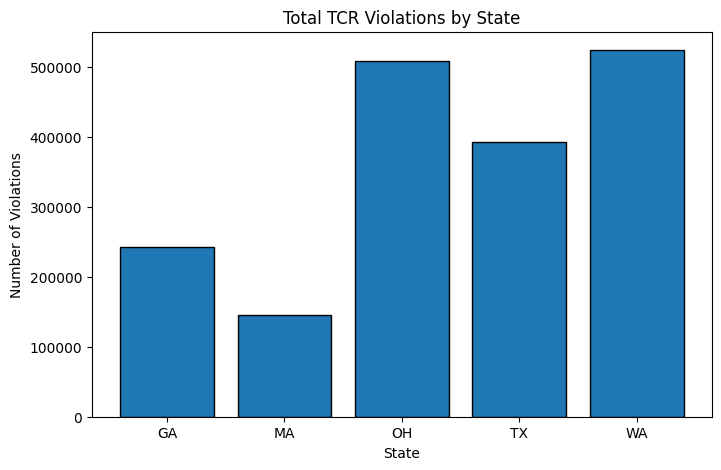

In [12]:
plt.figure(figsize=(8,5))

plt.bar(violations_by_state['State'], violations_by_state['Total Violations'], edgecolor='black')

plt.xlabel("State")
plt.ylabel("Number of Violations")
plt.title("Total TCR Violations by State")

plt.show()

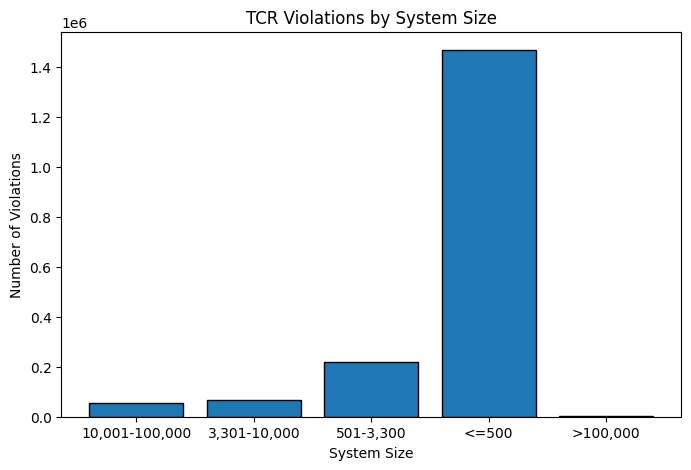

In [13]:
plt.figure(figsize=(8,5))

plt.bar(violations_by_popcat['System Size'], violations_by_popcat['Total Violations'], edgecolor='black')

plt.xlabel("System Size")
plt.ylabel("Number of Violations")
plt.title("TCR Violations by System Size")

plt.xticks(rotation=0)

plt.show()

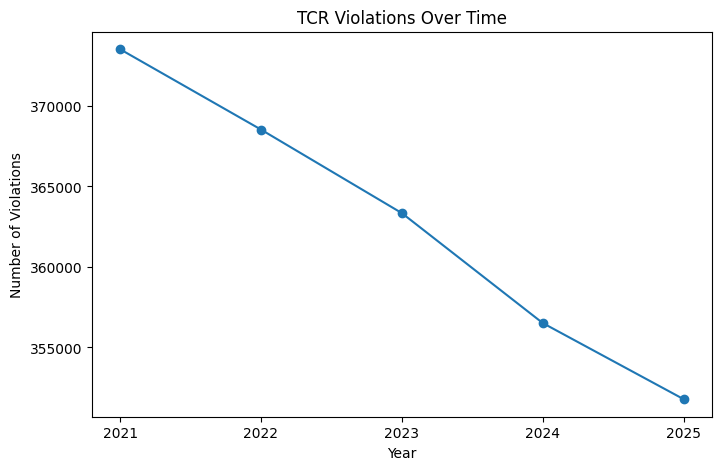

In [14]:
plt.figure(figsize=(8,5))

plt.plot(violations_by_year['Year'], violations_by_year['Total Violations'], marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.title("TCR Violations Over Time")

plt.show()

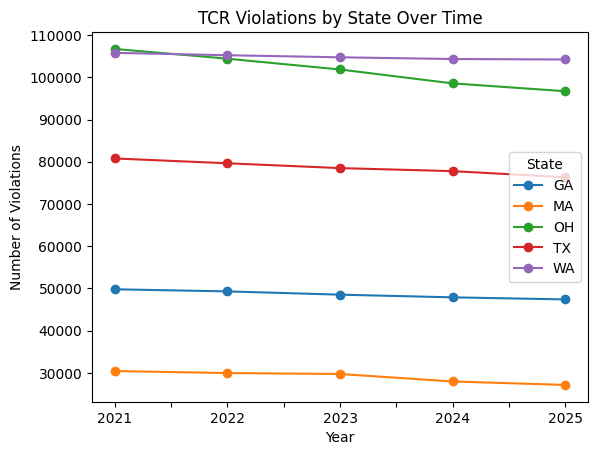

In [15]:
state_year = vio_data.groupby(['primacy_agency_code', 'year']).size().unstack()

state_year.T.plot(marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.title("TCR Violations by State Over Time")

plt.legend(title="State")
plt.show()

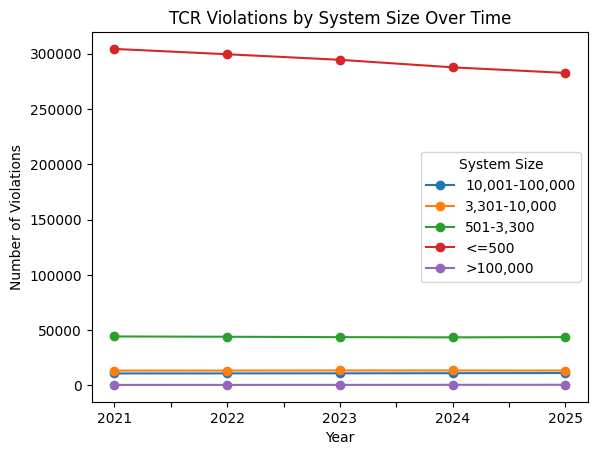

In [16]:
size_year = vio_data.groupby(['pop_cat_5', 'year']).size().unstack()

size_year.T.plot(marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.title("TCR Violations by System Size Over Time")

plt.legend(title="System Size")
plt.show()

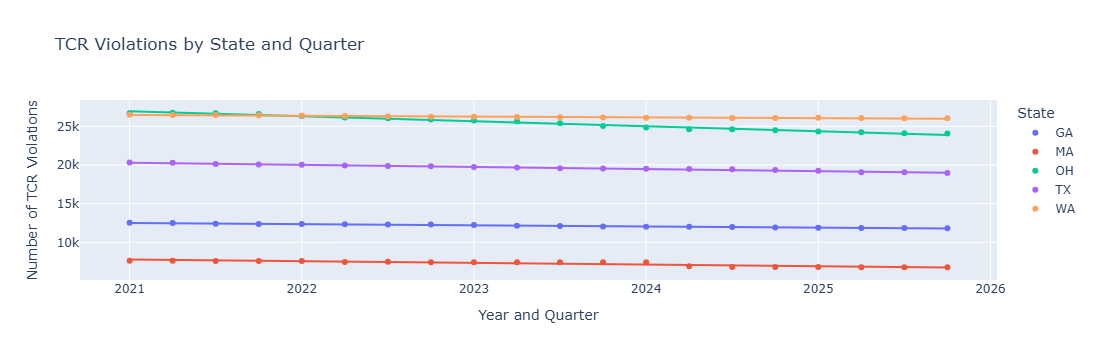

In [17]:
state_quarter = (
    vio_data
    .groupby(['primacy_agency_code', 'submission_year_quarter'])
    .size()
    .reset_index(name='total_violations')
)


state_quarter['quarter_number'] = (
    state_quarter['submission_year_quarter'].str[:4].astype(int)
    + (state_quarter['submission_year_quarter'].str[-1].astype(int) - 1) / 4
)

fig = px.scatter(
    state_quarter,
    x='quarter_number',
    y='total_violations',
    color='primacy_agency_code',
    trendline='ols',
    hover_name='submission_year_quarter',
    title='TCR Violations by State and Quarter',
    labels={
        'quarter_number': 'Year and Quarter',
        'total_violations': 'Number of TCR Violations',
        'primacy_agency_code': 'State'
    }
)

fig.show()